# Acquisition Function Output Analysis

Load a saved active-learning `output_dict` HDF5 file and start with the mean test reduced-error plot.

In [67]:
%matplotlib inline

from pathlib import Path
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt


cwd = Path.cwd()
stm_dir = cwd / "notebooks" / "STM" if (cwd / "notebooks" / "STM").exists() else cwd
results_dir = stm_dir  / "active_learning_results_eachSnorm_ms"

h5_files = sorted(results_dir.glob("*.h5"), key=lambda path: path.stat().st_mtime)
if not h5_files:
    raise FileNotFoundError(f"No .h5 files found in {results_dir}")


# By default, analyze the newest saved acquisition result. Replace this with
# a specific Path(...) if you want to load a different run.
output_file = h5_files[-1]
output_file



error_type = "L1"  # "L1", "L2", or "cos"
acquisition_iterations = 50
num_new_points = 5
output_file = results_dir / (
    f"al_im2spec_{error_type}_WS32_latent5_appendpad_"
    f"{acquisition_iterations}iters_{num_new_points}pts_distanceacq.h5"
)
print(output_file)

/Users/8ij/nnerror/NN_Error/notebooks/STM/active_learning_results_eachSnorm_ms/al_im2spec_L1_WS32_latent5_appendpad_50iters_5pts_distanceacq.h5


In [68]:
def plot_reduced_errors_and_scales(errors, coords_reduced, aq_indices=None):
    xs = coords_reduced[:, 0]
    ys = coords_reduced[:, 1]
    scales = coords_reduced[:, 2]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc0 = axes[0].scatter(xs, ys, c=errors, s=80)
    axes[0].set_title("Reduced Minimum Errors, mean = {:.3f}".format(np.mean(errors)))
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")
    plt.colorbar(sc0, ax=axes[0], label="Minimum Error")

    sc1 = axes[1].scatter(xs*0.4833, ys*0.4833, c=scales, s=80)
    axes[1].set_title("Best Scale at Each (x, y)")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].set_aspect("equal")
    plt.colorbar(sc1, ax=axes[1], label="Best Scale")

    if aq_indices is not None and len(aq_indices) > 0:
        aq_indices = np.asarray(aq_indices, dtype=int)

        axes[0].scatter(
            xs[aq_indices],
            ys[aq_indices],
            marker="x",
            s=120,
            linewidths=2,
            label="Acquisition points",
        )
        axes[0].legend()

    plt.tight_layout()
    plt.show()


def load_h5_ragged(filename):
    data_dict = {}

    with h5py.File(filename, "r") as f:
        for key in f.keys():
            group = f[key]

            values = []
            for i in range(len(group)):
                values.append(group[str(i)][()])

            data_dict[key] = values

    return data_dict


def infer_num_new_points(output_dict, output_file, fallback=5):
    match = re.search(r"_(\d+)pts_", output_file.name)
    if match:
        return int(match.group(1))

    train_indices = output_dict.get("train_indices", [])
    if len(train_indices) > 1:
        return int(len(train_indices[1]) - len(train_indices[0]))

    return fallback



In [69]:


output_dict = load_h5_ragged(output_file)
{key: len(value) for key, value in output_dict.items()}

{'im2spec_test_mismatches': 50,
 'pred_error_test': 50,
 'predicted_errors_all': 50,
 'reduced_coords': 50,
 'reduced_errors': 50,
 'reduced_errors_im2spec': 50,
 'test_indices': 50,
 'train_indices': 50}

(347,)
245
[ 233  118  128  131  631  159  644  866  707   86   85  774  740  409
  842   62  995   54  196  738  679  781  714  839 1003  992  832  736
  801  833  596 1005  941  973  715   88  111   25  967  916   39   38
   47   46   45  935  142  678  988  170  126  125  599  624  197   65
  119  203  120  202  137  594  140  460   29  706  990  927 1022  703
  234  807  685 1001  680   89  929   94  470  629  563  422  421  353
  132  310  611  587  171   70  457  809  623   72  994  630   51   23
   53   92    7    8   68  122    9  103  758  726  822  144  232  868
  745  648  877  632  112  806  837  746  684  662  971  791  709  899
  695 1019  926 1021  379  356  148  133  261  101  357  748  969  165
  864  960  768  704   52  522   57  574  778  835  843  796  412 1000
  275  770  859  823  798  986  141  633  158  109  157  542  597  593
   18  541  502  666  665  150  667  117  256    5  116    4  544  221
  616  643  535  881  664  869  653  650  151   50   66   36  896 

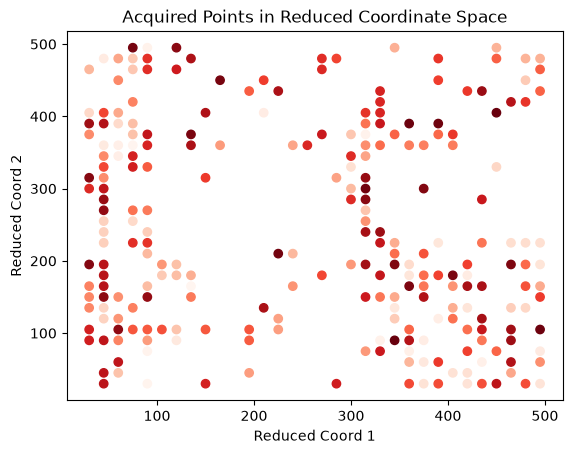

In [70]:
train_indices = output_dict.get("train_indices")

acquired_indices = [ind for ind in train_indices[-1] if ind not in train_indices[0]]

print(train_indices[-1].shape)
print(len(acquired_indices))

acquired_indices = np.array(acquired_indices)
print(acquired_indices)
acq_coords = output_dict["reduced_coords"][-1][acquired_indices]
# print(acq_coords.shape)
# print(acq_coords)
fig, ax = plt.subplots()
ax.scatter(acq_coords[:, 0], acq_coords[:, 1], c=np.arange(len(acq_coords)),  cmap = 'Reds', marker="o")
ax.set_xlabel("Reduced Coord 1")
ax.set_ylabel("Reduced Coord 2")
ax.set_title("Acquired Points in Reduced Coordinate Space")
plt.show()

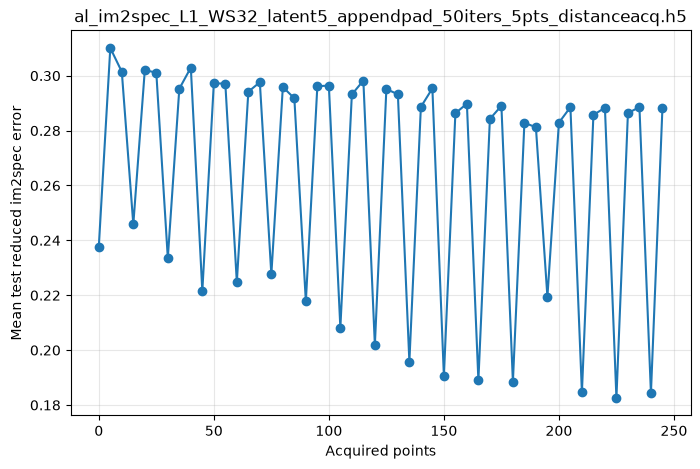

In [71]:


train_indices_arr = output_dict["train_indices"]
test_indices_arr = [indices.astype(int) for indices in output_dict["test_indices"]]
reduced_errors_arr = np.array(output_dict["reduced_errors_im2spec"])

num_saved_iterations = len(reduced_errors_arr)
points_per_iteration = infer_num_new_points(output_dict, output_file)

test_reduced_errors = [
    reduced_errors_arr[i][test_indices_arr[i]]
    for i in range(num_saved_iterations)
]

mean_test_reduced_errors = [
    np.mean(test_reduced_errors[i])
    for i in range(num_saved_iterations)
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(num_saved_iterations) * points_per_iteration,
    mean_test_reduced_errors,
    marker="o",
)
ax.set_xlabel("Acquired points")
ax.set_ylabel("Mean test reduced im2spec error")
ax.set_title(Path(output_file).name)
ax.grid(True, alpha=0.3)
plt.show()

In [72]:
output_file

PosixPath('/Users/8ij/nnerror/NN_Error/notebooks/STM/active_learning_results_eachSnorm_ms/al_im2spec_L1_WS32_latent5_appendpad_50iters_5pts_distanceacq.h5')

# Set plot_iteration

In [73]:
plot_iteration = 1

Plotting iteration 1 from al_im2spec_L1_WS32_latent5_appendpad_50iters_5pts_distanceacq.h5


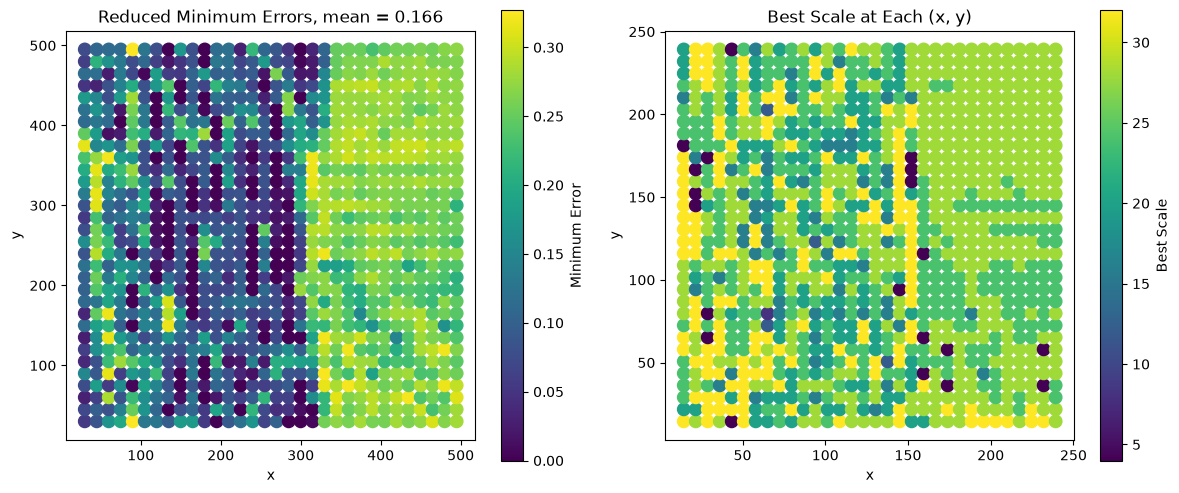

In [74]:

error_key = "reduced_errors"

if "reduced_coords" not in output_dict:
    raise KeyError(
        "This output file does not contain reduced_coords. "
        "Re-run stm_ms_acqfn_script.py after the reduced_coords save change."
    )

reduced_errors_to_plot = np.asarray(output_dict[error_key][plot_iteration])
reduced_coords_to_plot = np.asarray(output_dict["reduced_coords"][plot_iteration])

print(f"Plotting iteration {plot_iteration} from {Path(output_file).name}")
plot_reduced_errors_and_scales(reduced_errors_to_plot, reduced_coords_to_plot)

# Get original data

In [75]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, im2spec_attn
from nnerror.networks.custom_nn import CustomCNN
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [76]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis
def running_on_colab():
    return False

In [77]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [78]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 200
n_epochs_error = 200
error_type = "cos" # "L1", "L2", or "cos"
model_type = 'im2spec'
append_image_type = "pad" if model_type == 'im2spec' or 'im2spec_attn' or 'CustomCNN' else "interpolate" #pad, interpolate
use_swa = True
latent_dim = 5
last_swa_epochs = 100

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


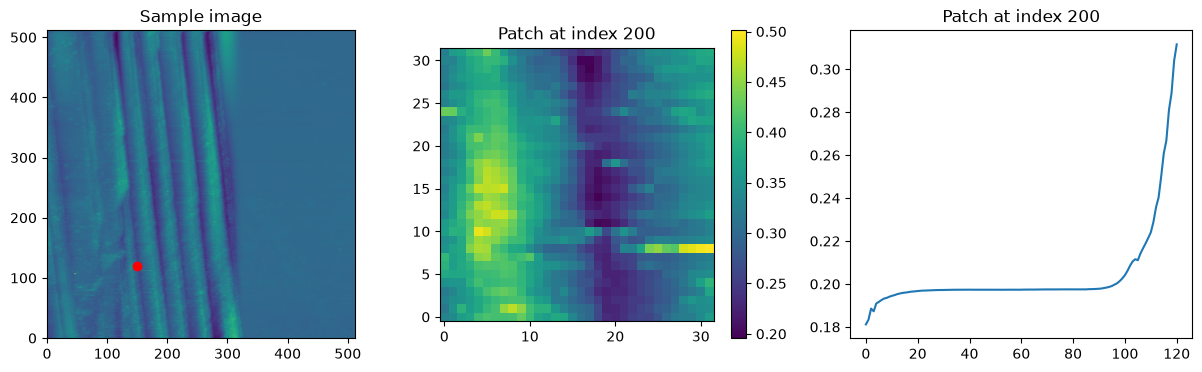

In [79]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [80]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

In [81]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

In [82]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


# Plot 3D

In [83]:
predicted_errors = output_dict['predicted_errors_all'][plot_iteration]



In [84]:
import numpy as np
from nnerror.training_functions import distance_acq_fn


plot_aq_ind, plot_aq_fn = distance_acq_fn(predicted_errors,
                                        beta=1,
                                        lambda_=1,
                                        sample_next_points=10,
                                        exclude_indices=[])

print("Shape of plot_aq_fn:", plot_aq_fn.shape)
print("Shape of plot_aq_ind:", plot_aq_ind.shape)

Shape of plot_aq_fn: (8192,)
Shape of plot_aq_ind: (10,)


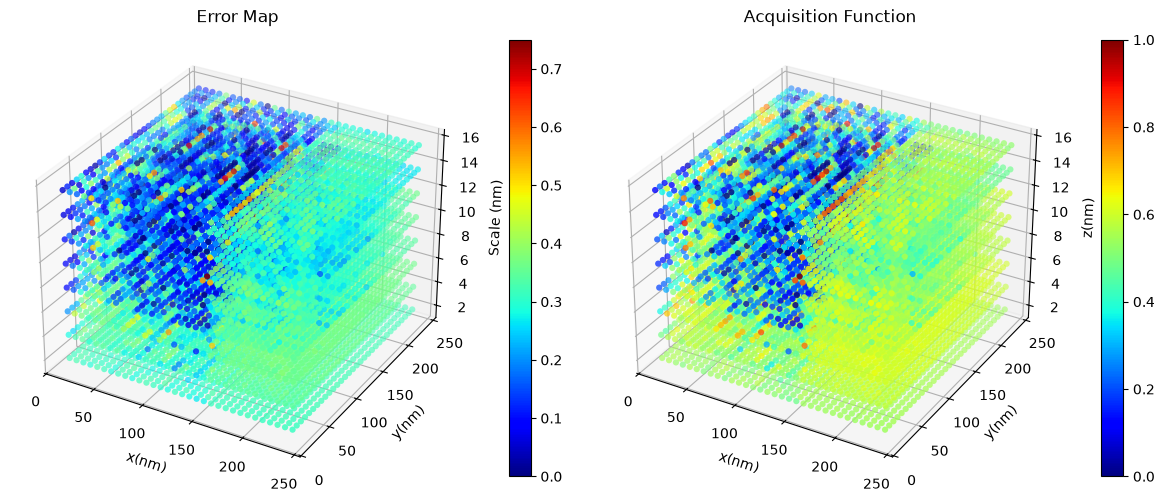

In [85]:
plot_error_prediction_3d(predicted_errors.reshape(-1,1), plot_aq_fn, scale_coordinates, plot_aq_ind, alpha_scale = False, colormap = 'jet')

# Visualize spatial coords

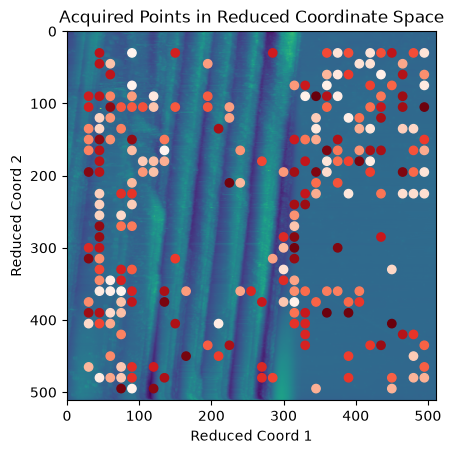

In [86]:
train_indices = output_dict.get("train_indices")

acquired_indices = [ind for ind in train_indices[-1] if ind not in train_indices[0]]

# print(train_indices[-1].shape)
# print(len(acquired_indices))

acquired_indices = np.array(acquired_indices)
# print(acquired_indices)
acq_coords = output_dict["reduced_coords"][-1][acquired_indices]
# print(acq_coords.shape)
# print(acq_coords)
fig, ax = plt.subplots()
ax.imshow(full_image)
ax.scatter(acq_coords[:, 0], acq_coords[:, 1], c=np.arange(len(acq_coords)),  cmap = 'Reds', marker="o")
ax.set_xlabel("Reduced Coord 1")
ax.set_ylabel("Reduced Coord 2")
ax.set_title("Acquired Points in Reduced Coordinate Space")
plt.show()